# Install Libraries

In [1]:
!pip install ultralytics scikit-learn seaborn

# Import Libraries

In [1]:
from ultralytics import YOLO
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns

# Load Both Models

In [2]:
person_model = YOLO( "../YOLOV8-PersonDetect/runs/detect/person_detector/weights/best.pt")

fall_model = YOLO("../YOLOV8-FallDetect/runs/detect/fall_detection/weights/best.pt")

# Define Class Names

In [3]:
class_names = ["fall", "walk", "sit"]

# Load Test Image

In [4]:
test_folder = "dataset/fall_dataset/images/test"
label_folder = "dataset/fall_dataset/labels/test"

# Prepare Lists

In [5]:
y_true = []
y_pred = []

# Run Two-Step Pipeline

In [7]:
# ==========================================
# RUN TWO-STEP PIPELINE
# ==========================================

for image_name in os.listdir(test_folder):

    image_path = os.path.join(test_folder, image_name)

    image = cv2.imread(image_path)

    if image is None:
        continue

    # ==========================================
    # GET TRUE LABEL
    # ==========================================

    base_name = os.path.splitext(image_name)[0]

    label_path = os.path.join(
        label_folder,
        base_name + ".txt"
    )

    if not os.path.exists(label_path):
        print(f"Label not found: {label_path}")
        continue

    with open(label_path, "r") as f:
        line = f.readline().strip()

    true_class_id = int(line.split()[0])

    true_label = class_names[true_class_id]

    # ==========================================
    # STEP 1: PERSON DETECTION
    # ==========================================

    detection_results = person_model(image)

    predicted_label = "unknown"

    for box in detection_results[0].boxes:

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # Crop detected person
        person_crop = image[y1:y2, x1:x2]

        # Skip empty crop
        if person_crop.size == 0:
            continue

        # ==========================================
        # STEP 2: FALL DETECTION
        # ==========================================

        fall_results = fall_model(person_crop)

        if len(fall_results[0].boxes) > 0:

            # Select highest confidence detection
            best_box = max(
                fall_results[0].boxes,
                key=lambda b: float(b.conf[0])
            )

            cls_id = int(best_box.cls[0])

            predicted_label = fall_results[0].names[cls_id]

            # Normalize class names
            if predicted_label == "fall detected":
                predicted_label = "fall"

        break

    y_true.append(true_label)
    y_pred.append(predicted_label)

    print(
        f"{image_name} | TRUE: {true_label} | PRED: {predicted_label}"
    )


0: 288x416 3 fall detecteds, 1 walk, 58.1ms
Speed: 21.9ms preprocess, 58.1ms inference, 1.4ms postprocess per image at shape (1, 3, 288, 416)

0: 448x640 1 fall detected, 1 walk, 147.0ms
Speed: 2.5ms preprocess, 147.0ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)
fall_001.jpg | TRUE: fall | PRED: fall

0: 288x416 2 fall detecteds, 37.2ms
Speed: 1.0ms preprocess, 37.2ms inference, 0.8ms postprocess per image at shape (1, 3, 288, 416)

0: 480x640 1 sit, 151.8ms
Speed: 2.3ms preprocess, 151.8ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
fall_002.jpg | TRUE: fall | PRED: sit

0: 288x416 1 walk, 35.1ms
Speed: 1.4ms preprocess, 35.1ms inference, 1.1ms postprocess per image at shape (1, 3, 288, 416)

0: 640x544 1 sit, 144.7ms
Speed: 3.9ms preprocess, 144.7ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 544)
fall_003.jpg | TRUE: fall | PRED: sit

0: 416x288 1 fall detected, 1 walk, 30.3ms
Speed: 1.4ms preprocess, 30.3ms inference, 0.9m

Generate Confusion Matrix


Accuracy: 59.02%

Classification Report:

              precision    recall  f1-score   support

        fall       0.80      0.47      0.59        60
        walk       0.59      0.79      0.68        61
         sit       0.67      0.52      0.58        62

   micro avg       0.66      0.59      0.62       183
   macro avg       0.69      0.59      0.62       183
weighted avg       0.69      0.59      0.62       183


Classification report saved.


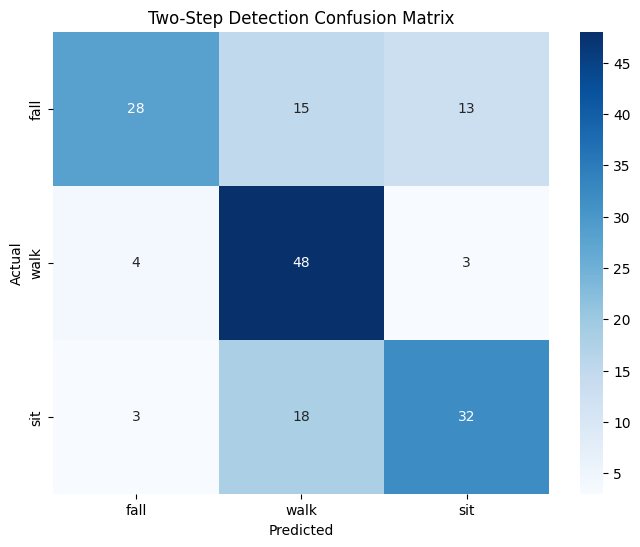

Confusion matrix image saved.


In [9]:
# ==========================================
# CALCULATE ACCURACY
# ==========================================

accuracy = accuracy_score(y_true, y_pred)

print(f"\nAccuracy: {accuracy * 100:.2f}%")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

report = classification_report(
    y_true,
    y_pred,
    labels=class_names,
    zero_division=0
)

print("\nClassification Report:\n")
print(report)

# Save report
with open("classification_report.txt", "w") as f:
    f.write(report)

print("\nClassification report saved.")

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=class_names
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Two-Step Detection Confusion Matrix")

# Save image FIRST
plt.savefig(
    "two_step_confusion_matrix.png",
    bbox_inches="tight"
)

# Then show
plt.show()

print("Confusion matrix image saved.")